In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import shap
import joblib
from sklearn.preprocessing import StandardScaler

# Load saved model and scaler
xgb_model = joblib.load(r'C:\Users\boser\Desktop\Project_Carbon\models\xgb_tuned.pkl')
scaler     = joblib.load(r'C:\Users\boser\Desktop\Project_Carbon\models\scaler.pkl')

df = pd.read_csv(
    r'C:\Users\boser\Desktop\Project_Carbon\data\processed\final_dataset_engineered.csv',
    index_col='date', parse_dates=True
).sort_index()

FEATURES = [
    'gas_price_lag1', 'gas_price_volatility', 'vix', 'co2_change',
    'days_to_next_cop', 'cop_urgency', 'is_cop_week',
    'recent_volatility', 'momentum_4w', 'momentum_12w', 'regime'
]
TARGET = 'carbon_price_change_pct'

df = df.dropna(subset=FEATURES + [TARGET])

SPLIT_DATE = '2023-01-01'
X_train = df.loc[df.index <  SPLIT_DATE, FEATURES]
X_test  = df.loc[df.index >= SPLIT_DATE, FEATURES]
y_test  = df.loc[df.index >= SPLIT_DATE, TARGET]

X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURES, index=X_test.index)

In [4]:
# ── Build SHAP Explainer ────────────────────────────────────────────────────
# WHY TreeExplainer specifically:
# SHAP has multiple explainer types — KernelExplainer works on any model
# but is slow (uses Monte Carlo sampling). TreeExplainer is exact and fast
# because it exploits the tree structure directly — it knows exactly which
# leaf each sample lands on and how each split contributed to that outcome.
# For XGBoost, TreeExplainer is always the correct choice.

explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values on the test set
# shap_values shape: (173, 11) — one row per test week, one column per feature
# Each value = how much that feature pushed the prediction away from the base value
shap_values = explainer.shap_values(X_test_sc)

# Base value = what the model predicts when it knows nothing (training mean)
base_value = explainer.expected_value
print(f"Base value (model's average prediction): {base_value:.4f}%")
print(f"SHAP values shape: {shap_values.shape}")

# Sanity check: base + sum of SHAP values = model prediction
# This must hold for every row — it's the fundamental SHAP property
predictions = xgb_model.predict(X_test_sc)
check_row = 0
shap_sum = base_value + shap_values[check_row].sum()
print(f"\nSanity check (row 0):")
print(f"  Base + SHAP sum : {shap_sum:.4f}%")
print(f"  Model prediction: {predictions[check_row]:.4f}%")
print(f"  Match: {np.isclose(shap_sum, predictions[check_row], atol=1e-3)}")

Base value (model's average prediction): 0.7904%
SHAP values shape: (173, 11)

Sanity check (row 0):
  Base + SHAP sum : -3.1192%
  Model prediction: -3.1192%
  Match: True


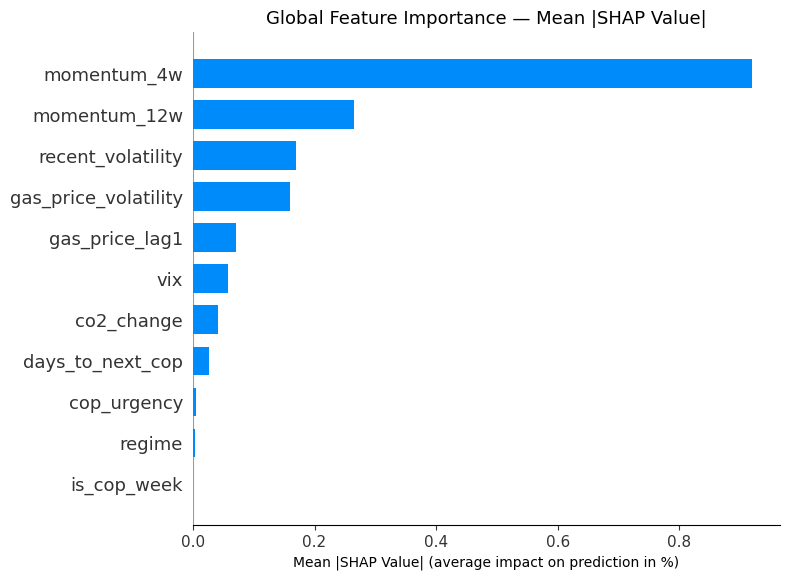

In [5]:
# ── Plot 1: Global Feature Importance — SHAP Bar Plot ──────────────────────
# WHY this is better than model.feature_importances_:
# XGBoost's built-in importance is based on how often a feature is used
# to split across all trees — it doesn't tell you the MAGNITUDE of impact.
# SHAP mean absolute value tells you: on average, how many % points does
# this feature move the prediction. That's directly interpretable.

shap.summary_plot(
    shap_values,
    X_test_sc,
    plot_type='bar',
    feature_names=FEATURES,
    show=False
)
plt.title('Global Feature Importance — Mean |SHAP Value|', fontsize=13)
plt.xlabel('Mean |SHAP Value| (average impact on prediction in %)', fontsize=10)
plt.tight_layout()
plt.show()

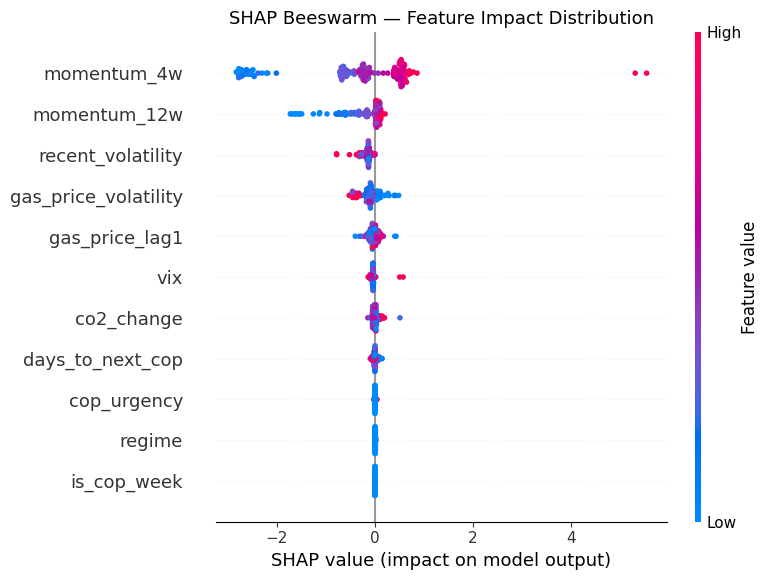

In [6]:
# ── Plot 2: SHAP Beeswarm / Summary Plot ───────────────────────────────────
# WHY: The bar plot shows magnitude but not direction or distribution.
# The beeswarm shows:
#   - X axis: SHAP value (positive = pushed price up, negative = pushed down)
#   - Color: actual feature value (red = high, blue = low)
#   - Each dot = one week in the test set
#
# So you can read: "when momentum_4w is high (red), SHAP is strongly positive
# (right side) — high momentum pushes the prediction upward."
# This reveals the direction and non-linearity of each feature's effect.

shap.summary_plot(
    shap_values,
    X_test_sc,
    feature_names=FEATURES,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Distribution', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ── Plot 3: SHAP Waterfall — Single Prediction Explained ───────────────────
# WHY: Global plots tell you average behaviour. The waterfall tells you
# WHY the model made ONE specific prediction. This is the core of XAI —
# local explanation. Each bar shows how much that feature pushed the
# prediction above or below the base value for that specific week.

# Let's explain a few interesting weeks
# First: find the week with the highest predicted % change (most bullish)
most_bullish_idx = predictions.argmax()
most_bearish_idx = predictions.argmin()

print(f"Most bullish week: {X_test_sc.index[most_bullish_idx].date()} | Prediction: {predictions[most_bullish_idx]:.4f}%")
print(f"Most bearish week: {X_test_sc.index[most_bearish_idx].date()} | Prediction: {predictions[most_bearish_idx]:.4f}%")

Most bullish week: 2024-04-07 | Prediction: 6.2782%
Most bearish week: 2024-02-11 | Prediction: -4.8049%


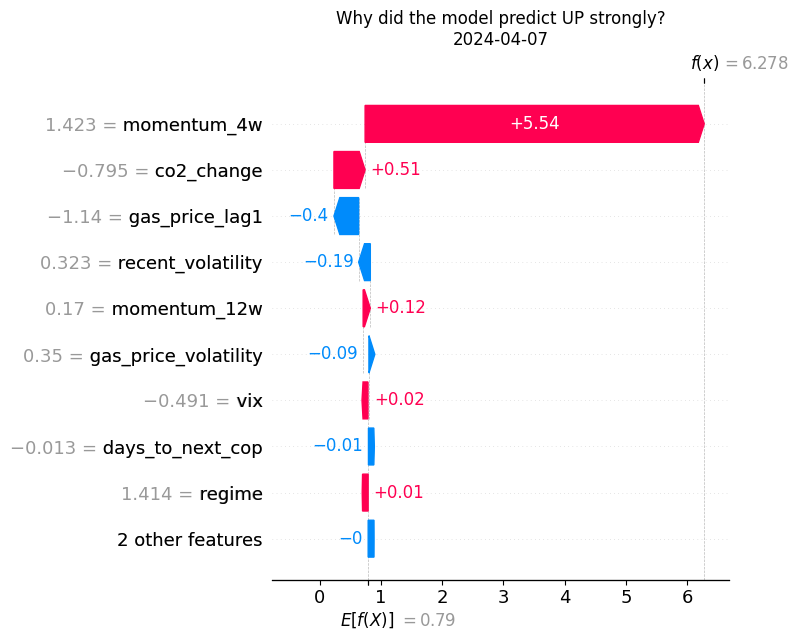

In [8]:
# Waterfall for most bullish prediction
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[most_bullish_idx],
        base_values = base_value,
        data        = X_test_sc.iloc[most_bullish_idx].values,
        feature_names = FEATURES
    ),
    show=False
)
plt.title(f"Why did the model predict UP strongly?\n{X_test_sc.index[most_bullish_idx].date()}", fontsize=12)
plt.tight_layout()
plt.show()

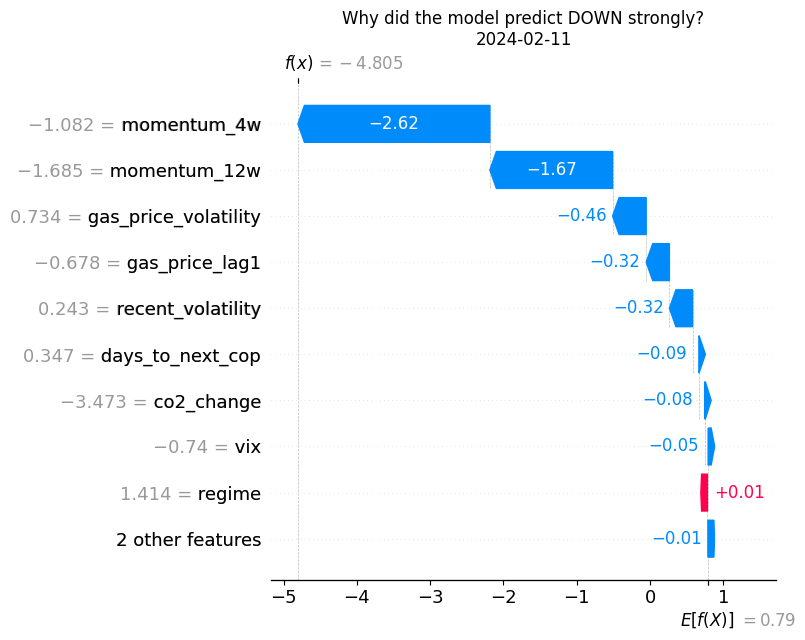

In [9]:
# Waterfall for most bearish prediction
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[most_bearish_idx],
        base_values = base_value,
        data        = X_test_sc.iloc[most_bearish_idx].values,
        feature_names = FEATURES
    ),
    show=False
)
plt.title(f"Why did the model predict DOWN strongly?\n{X_test_sc.index[most_bearish_idx].date()}", fontsize=12)
plt.tight_layout()
plt.show()

Worst prediction week : 2023-12-17
  Predicted : 0.1860%
  Actual    : 13.8671%
  Error     : 13.6811%


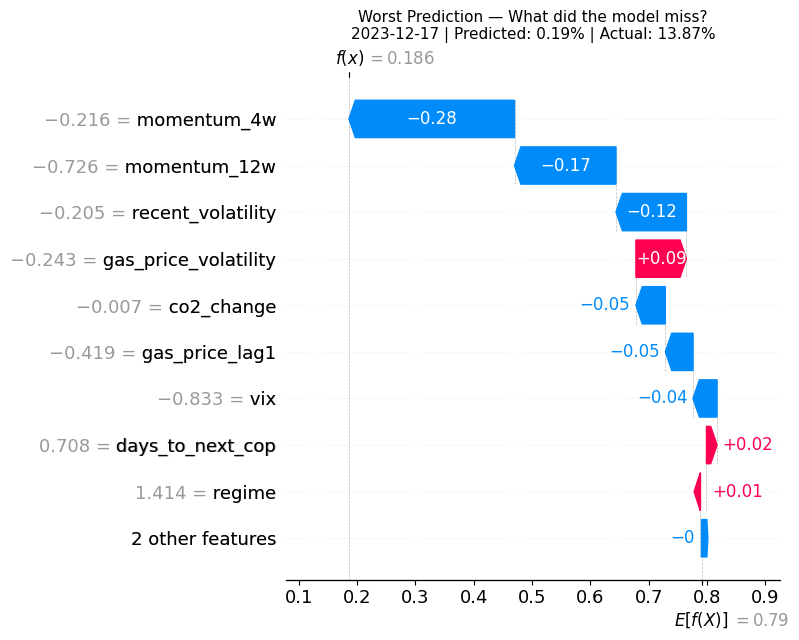

In [10]:
# Waterfall for a week where actual and predicted diverged most
# This is the most educational — where did the model go wrong and why?
actual_vals   = y_test.values
errors        = np.abs(predictions - actual_vals)
worst_pred_idx = errors.argmax()

print(f"Worst prediction week : {X_test_sc.index[worst_pred_idx].date()}")
print(f"  Predicted : {predictions[worst_pred_idx]:.4f}%")
print(f"  Actual    : {actual_vals[worst_pred_idx]:.4f}%")
print(f"  Error     : {errors[worst_pred_idx]:.4f}%")

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[worst_pred_idx],
        base_values = base_value,
        data        = X_test_sc.iloc[worst_pred_idx].values,
        feature_names = FEATURES
    ),
    show=False
)
plt.title(f"Worst Prediction — What did the model miss?\n"
          f"{X_test_sc.index[worst_pred_idx].date()} | Predicted: {predictions[worst_pred_idx]:.2f}% | Actual: {actual_vals[worst_pred_idx]:.2f}%",
          fontsize=11)
plt.tight_layout()
plt.show()

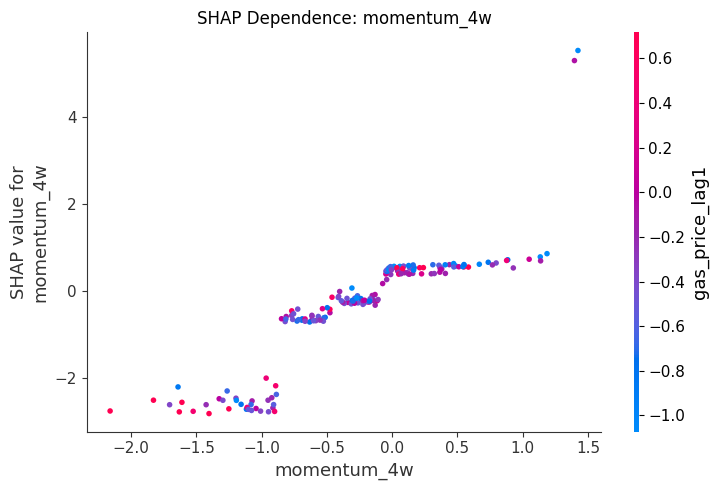

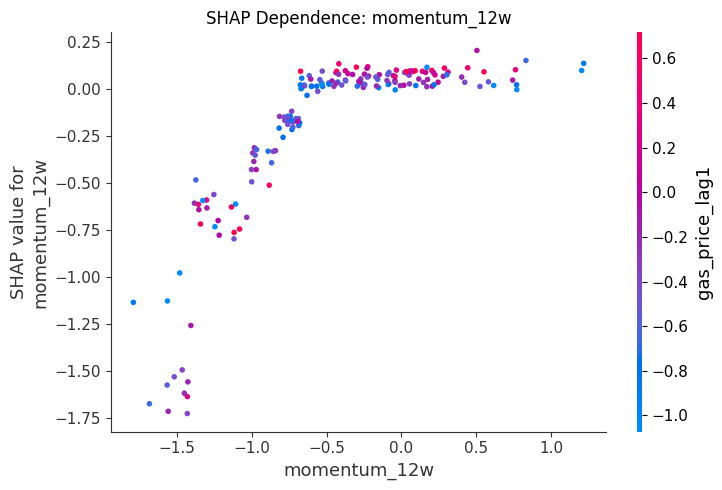

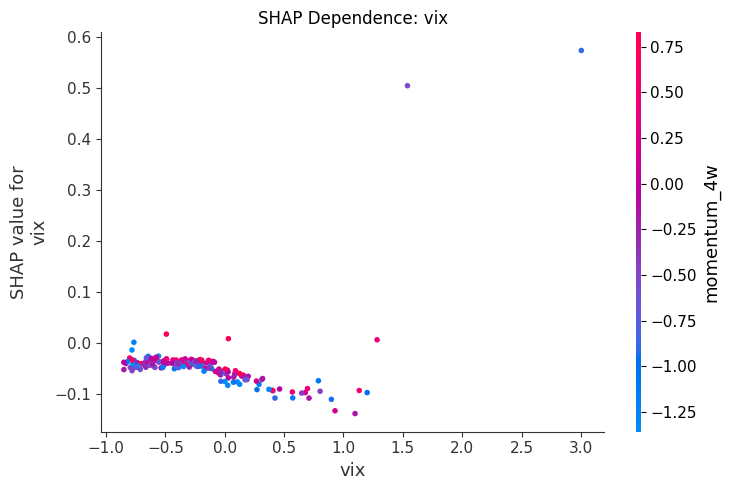

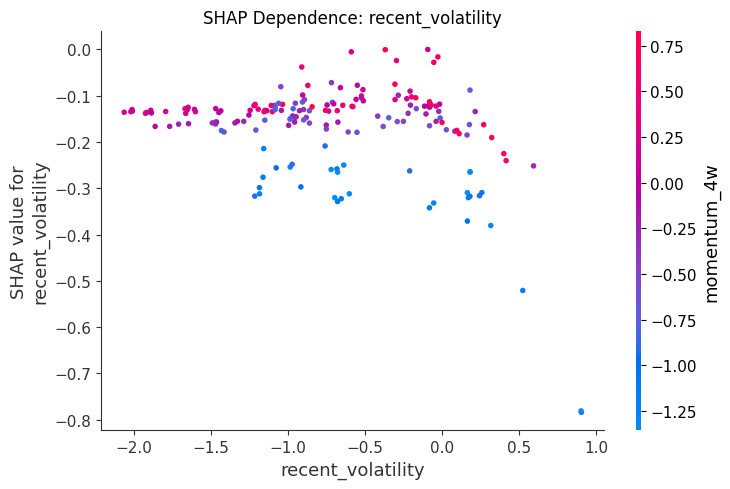

In [11]:
# ── Plot 4: SHAP Dependence Plot ────────────────────────────────────────────
# WHY: This answers "how does momentum_4w specifically affect predictions
# across the full range of its values?"
# X axis = actual feature value
# Y axis = SHAP value for that feature
# Color = a second feature (auto-selected for interaction — usually the
#         feature that most interacts with the x-axis feature)
#
# If the relationship were linear, you'd see a straight diagonal line.
# Any curve, step, or cluster reveals non-linearity or interaction effects
# that linear models like Lasso completely miss.

for feature in ['momentum_4w', 'momentum_12w', 'vix', 'recent_volatility']:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_sc,
        feature_names=FEATURES,
        show=False
    )
    plt.title(f'SHAP Dependence: {feature}', fontsize=12)
    plt.tight_layout()
    plt.show()

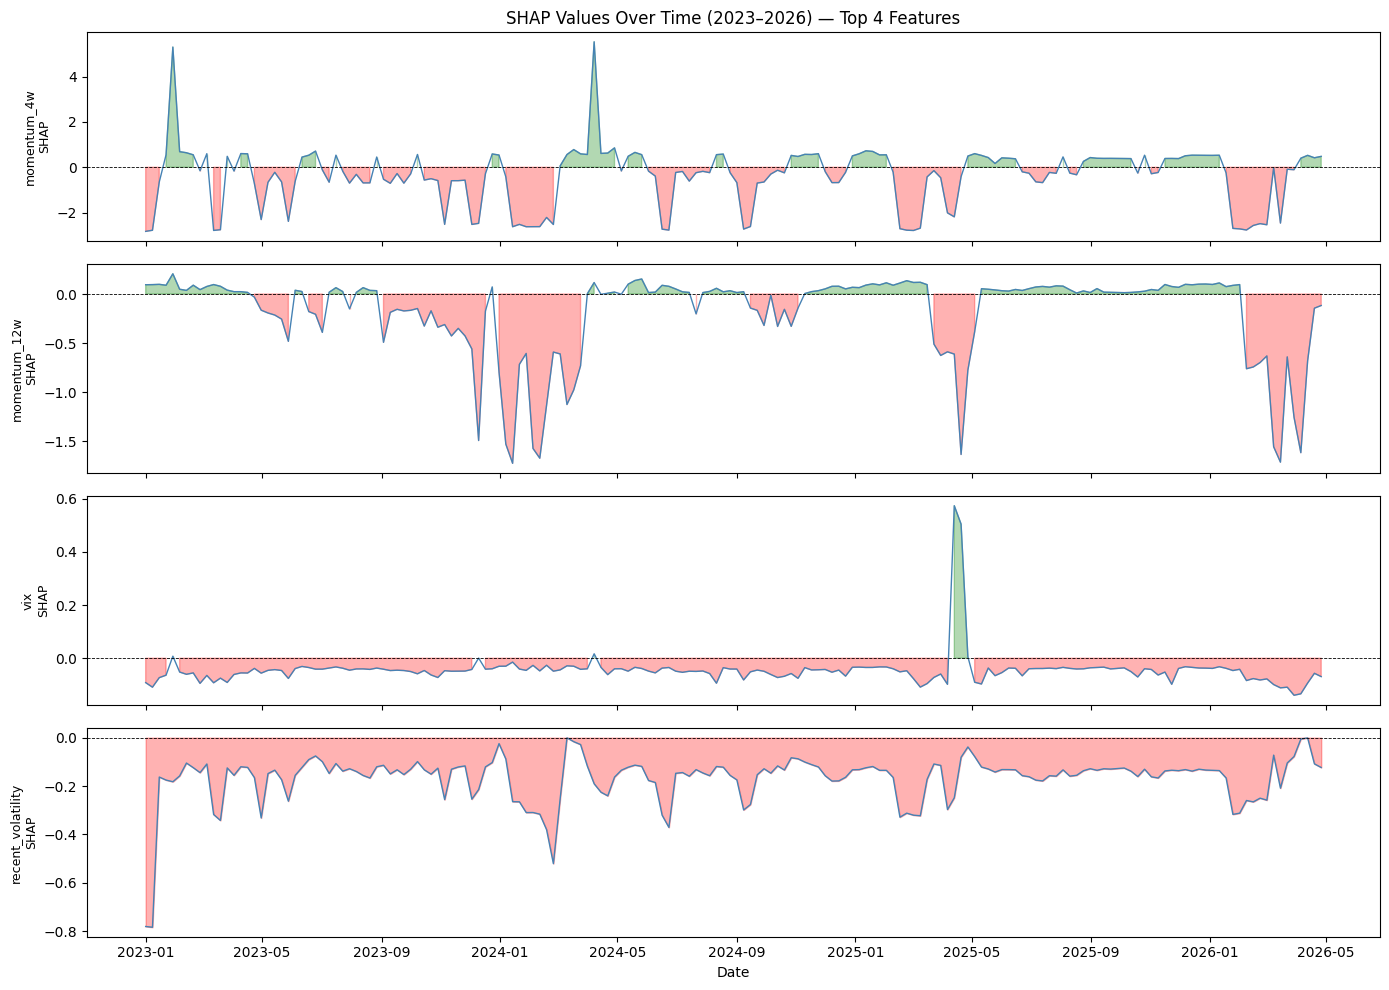

In [12]:
# ── Plot 5: SHAP Over Time ──────────────────────────────────────────────────
# WHY: This is unique to time series problems and not commonly shown.
# Plot the SHAP value of each feature across the test period (2023–2026).
# This tells you: was momentum driving predictions in early 2023 but VIX
# driving them in late 2024? Markets are non-stationary — the SHAP time
# series reveals if the drivers shifted over the test period.

shap_df = pd.DataFrame(shap_values, columns=FEATURES, index=X_test_sc.index)

# Plot top 4 features over time
top_features = ['momentum_4w', 'momentum_12w', 'vix', 'recent_volatility']

fig, axes = plt.subplots(len(top_features), 1, figsize=(14, 10), sharex=True)

for ax, feat in zip(axes, top_features):
    ax.plot(shap_df.index, shap_df[feat], color='steelblue', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.fill_between(shap_df.index, shap_df[feat], 0,
                    where=shap_df[feat] > 0, alpha=0.3, color='green')
    ax.fill_between(shap_df.index, shap_df[feat], 0,
                    where=shap_df[feat] < 0, alpha=0.3, color='red')
    ax.set_ylabel(f'{feat}\nSHAP', fontsize=9)

axes[0].set_title('SHAP Values Over Time (2023–2026) — Top 4 Features', fontsize=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [13]:
# ── Summary Table: SHAP Stats per Feature ──────────────────────────────────
# Clean printout for the notebook — useful for the About tab in the app

shap_stats = pd.DataFrame({
    'Mean SHAP'     : shap_df.mean(),
    'Mean |SHAP|'   : shap_df.abs().mean(),
    'Max SHAP'      : shap_df.max(),
    'Min SHAP'      : shap_df.min(),
    'Std SHAP'      : shap_df.std()
}).sort_values('Mean |SHAP|', ascending=False)

print("SHAP Summary Statistics — Test Set (2023–2026)")
print("=" * 65)
print(shap_stats.round(4).to_string())

SHAP Summary Statistics — Test Set (2023–2026)
                      Mean SHAP  Mean |SHAP|  Max SHAP  Min SHAP  Std SHAP
momentum_4w             -0.3755       0.9193    5.5380   -2.8281    1.2979
momentum_12w            -0.1917       0.2649    0.2066   -1.7268    0.4400
recent_volatility       -0.1694       0.1694   -0.0006   -0.7838    0.1022
gas_price_volatility    -0.1007       0.1601    0.4841   -0.5267    0.1767
gas_price_lag1          -0.0245       0.0707    0.4298   -0.4034    0.0946
vix                     -0.0447       0.0575    0.5733   -0.1393    0.0676
co2_change               0.0106       0.0414    0.5089   -0.1471    0.0666
days_to_next_cop         0.0029       0.0259    0.1427   -0.0960    0.0384
cop_urgency             -0.0009       0.0051    0.0380   -0.0183    0.0083
regime                   0.0034       0.0034    0.0104    0.0007    0.0025
is_cop_week              0.0000       0.0000    0.0000    0.0000    0.0000
